# CIFAR10 CNN PyTorch complete

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
print(torch.__version__)

2.11.0+cpu


In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [5]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [6]:
transet=torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

100%|██████████| 170M/170M [48:24<00:00, 58.7kB/s]


In [7]:
testset=torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)

In [8]:
batch=32
tran_loader=torch.utils.data.DataLoader(transet, batch_size=batch,
                                          shuffle=True, num_workers=2)
test_loader=torch.utils.data.DataLoader(testset, batch_size=batch,
                                          shuffle=False, num_workers=2)

In [9]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 6, 5)
    self.bn1 = nn.BatchNorm2d(6)
    self.conv2 = nn.Conv2d(6, 16, 5)
    self.bn2 = nn.BatchNorm2d(16)
    self.conv3 = nn.Conv2d(16, 120, 5)
    self.bn3 = nn.BatchNorm2d(120)

    self.maxpool = nn.MaxPool2d(2, 2)
    self.rulu = nn.ReLU()

    self.fc1 = nn.Linear(120, 84)
    self.fc2 = nn.Linear(84, 10)

  def forward(self, x):

    x = self.rulu(self.bn1(self.conv1(x)))
    x = self.maxpool(x)
    x = self.rulu(self.bn2(self.conv2(x)))
    x = self.maxpool(x)
    x = self.rulu(self.bn3(self.conv3(x)))
    x = x.view(x.size(0), -1)
    x = self.rulu(self.fc1(x))
    x = self.fc2(x)
    return x

model = CNN().to(device)
print(model)


In [10]:
model = CNN().to(device)

print(model)

CNN(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (rulu): ReLU()
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)


In [11]:
sample_images, sample_labels = next(iter(tran_loader))

sample_images = sample_images.to(device)

outputs = model(sample_images)

print("Input shape:", sample_images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 32, 32])
Output shape: torch.Size([32, 10])


In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [14]:
num_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    for images, labels in tran_loader:

        images = images.to(device)
        labels = labels.to(device)
        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_images += labels.size(0)

    epoch_loss = running_loss / len(tran_loader)

    epoch_accuracy = (
        correct_predictions / total_images
    ) * 100

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Streaming output truncated to the last 5000 lines.
)
optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differenti

In [18]:
model.eval()

correct_predictions = 0
total_images = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_images += labels.size(0)

test_accuracy = (
    correct_predictions / total_images
) * 100

print(f"Test accuracy: {test_accuracy:.2f}%")

Test accuracy: 63.27%


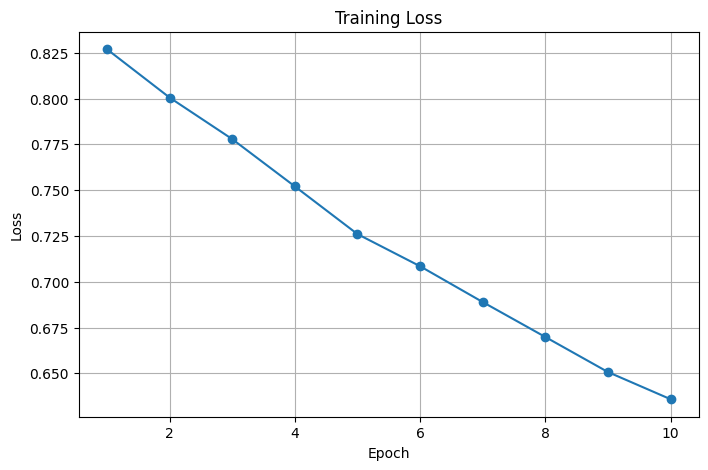

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid()

plt.show()

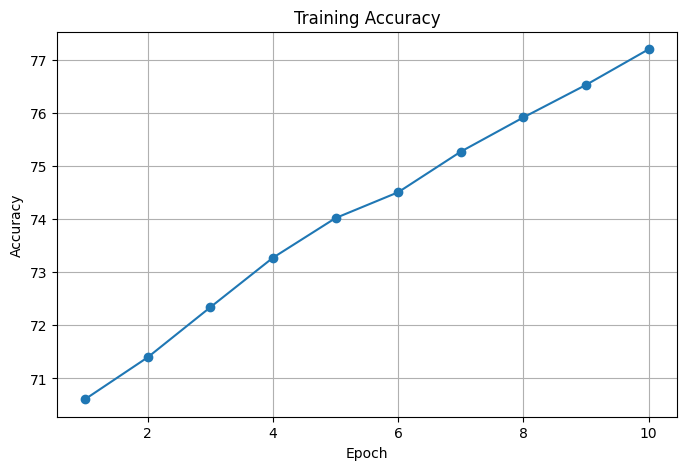

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.grid()

plt.show()

# Task
Improve the performance of the existing CIFAR-10 CNN model. The current model achieved a training accuracy of 77.19% and a test accuracy of 63.27% after 10 epochs. The plan includes analyzing current performance, implementing data augmentation, introducing batch normalization, adding dropout layers, considering model complexity or transfer learning, optimizing hyperparameters, training for more epochs, evaluating the final model, and summarizing the improvements.

## Analyze Current Model Performance

### Subtask:
Analyze the training loss, training accuracy, and test accuracy to understand the current model's performance and identify potential issues such as overfitting or underfitting.


### Current Model Performance Analysis

**Training Loss:**
The training loss plot shows a consistent decrease over the 10 epochs, starting from approximately 0.82 and ending at 0.63. This indicates that the model is learning and converging during the training process.

**Training Accuracy:**
The training accuracy plot shows a steady increase over the 10 epochs, starting from approximately 70.61% and reaching 77.19%. This also confirms that the model is effectively learning from the training data.

**Test Accuracy vs. Training Accuracy:**
The final training accuracy is 77.19%, while the test accuracy is 63.27%. There is a significant gap of approximately 14% between the training accuracy and the test accuracy. This discrepancy suggests that the model is likely **overfitting** to the training data. The model performs well on the data it has seen during training but struggles to generalize to unseen data.

**Conclusion:**
The model shows clear signs of overfitting. While it learns well on the training set, its performance significantly drops on the test set. This indicates a need for regularization techniques and possibly data augmentation to improve its generalization capabilities.

## Implement Data Augmentation

### Subtask:
Add data augmentation techniques to the training dataset to increase its effective size and help the model generalize better, thereby reducing overfitting.


**Reasoning**:
I need to define a new `transform_train` including data augmentation techniques and then update the `tran_loader` to use this new transform. Finally, I will verify the updated transform.



In [20]:
transform_train = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

# Update the training dataset with the new transform
transet_augmented = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)

# Update the training data loader
tran_loader = torch.utils.data.DataLoader(
    transet_augmented, batch_size=batch, shuffle=True, num_workers=2
)

print("Training data transform updated successfully.")
print("New transform_train:", transform_train)


Training data transform updated successfully.
New transform_train: Compose(
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)


## Introduce Batch Normalization

### Subtask:
Integrate BatchNorm layers after convolutional layers and before activation functions in your CNN architecture. Batch Normalization helps stabilize and speed up training, and can also act as a regularizer, making it beneficial for most deep learning models.
